# Disease Prediction Using Machine Learning

## CodeAlpha Machine Learning Internship Project

### Project Overview

This project develops a Machine Learning model capable of predicting the likelihood of heart disease based on patient clinical information. Multiple classification algorithms are trained and evaluated to identify the most accurate model. The final model is integrated into a Flask web application for real-time prediction.

---

### Objectives

- Perform Exploratory Data Analysis (EDA)
- Clean and preprocess the dataset
- Train multiple Machine Learning models
- Compare model performance
- Select the best-performing model
- Save the trained model
- Build a Flask-based web application

---

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost (Optional)
- Flask
- Joblib

In [1]:
# ============================================================
# Disease Prediction Using Machine Learning
# ============================================================

# ===========================
# Import Libraries
# ===========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC

import joblib

sns.set_style("whitegrid")

print("="*60)
print("Disease Prediction Project Initialized Successfully!")
print("="*60)

Disease Prediction Project Initialized Successfully!


In [3]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("heart.csv")

print("=" * 60)
print("Dataset Loaded Successfully!")
print("=" * 60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Loaded Successfully!
Rows    : 303
Columns : 14


In [4]:
# ============================================================
# Display Dataset
# ============================================================

print("\nFirst Five Records")
display(df.head())

print("\nLast Five Records")
display(df.tail())


First Five Records


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Last Five Records


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [5]:
# ============================================================
# Dataset Information
# ============================================================

print("\nDataset Information")
df.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
# ============================================================
# Statistical Summary
# ============================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [7]:
# ============================================================
# Missing Values
# ============================================================

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df)) * 100
})

display(missing_df)

,Missing Values,Percentage
age,0,0.0
sex,0,0.0
cp,0,0.0
trestbps,0,0.0
chol,0,0.0
fbs,0,0.0
restecg,0,0.0
thalach,0,0.0
exang,0,0.0
oldpeak,0,0.0


In [8]:
# ============================================================
# Duplicate Records
# ============================================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 1


In [9]:
# ============================================================
# Dataset Shape
# ============================================================

print(f"Total Records : {len(df)}")
print(f"Total Features : {df.shape[1]-1}")
print(f"Target Column : target")

Total Records : 303
Total Features : 13
Target Column : target


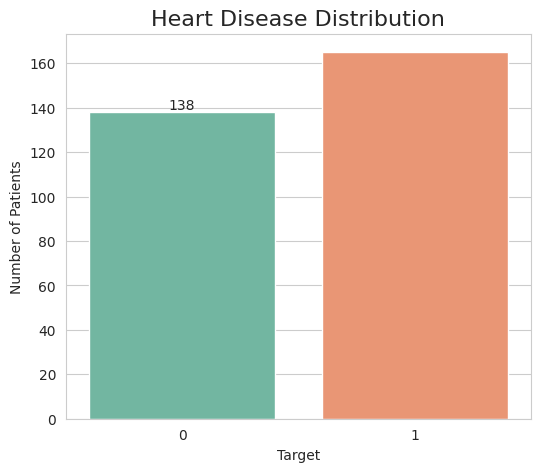

target
1    165
0    138
Name: count, dtype: int64


In [10]:
# ============================================================
# Target Variable Distribution
# ============================================================

plt.figure(figsize=(6,5))

ax = sns.countplot(
    x='target',
    data=df,
    palette='Set2'
)

plt.title("Heart Disease Distribution", fontsize=16)
plt.xlabel("Target")
plt.ylabel("Number of Patients")

ax.bar_label(ax.containers[0])

plt.show()

print(df['target'].value_counts())

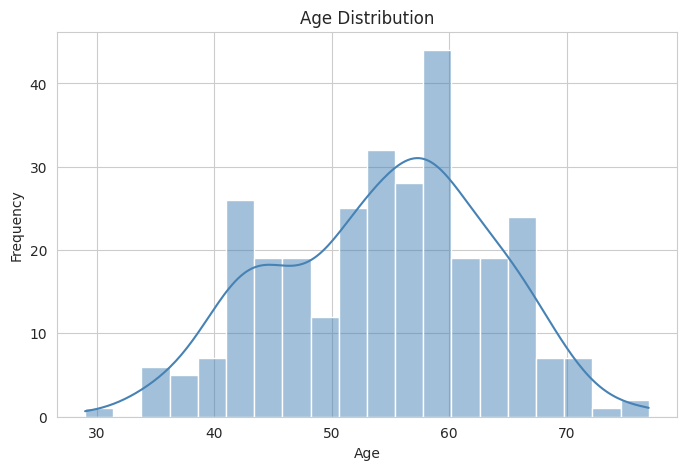

In [11]:
# ============================================================
# Age Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

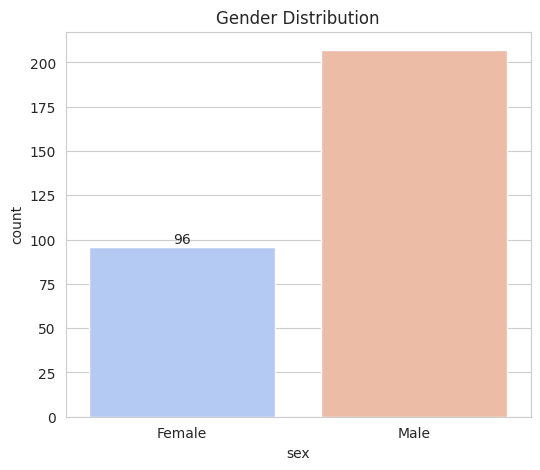

In [12]:
# ============================================================
# Gender Distribution
# ============================================================

plt.figure(figsize=(6,5))

ax = sns.countplot(
    x='sex',
    data=df,
    palette='coolwarm'
)

plt.title("Gender Distribution")

ax.set_xticklabels(["Female","Male"])

ax.bar_label(ax.containers[0])

plt.show()

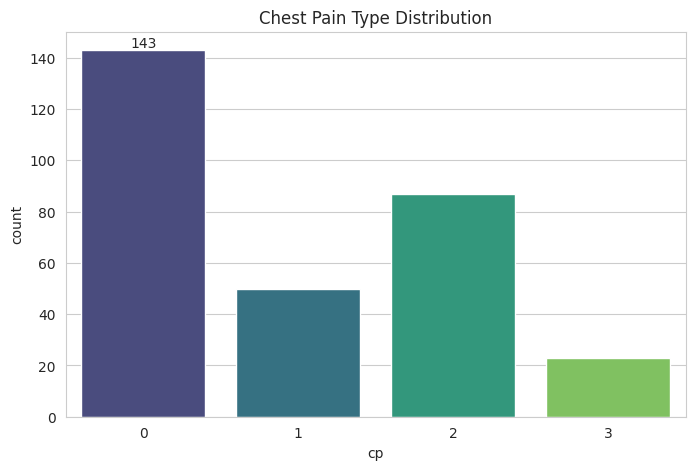

In [13]:
# ============================================================
# Chest Pain Type
# ============================================================

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='cp',
    data=df,
    palette='viridis'
)

plt.title("Chest Pain Type Distribution")

ax.bar_label(ax.containers[0])

plt.show()

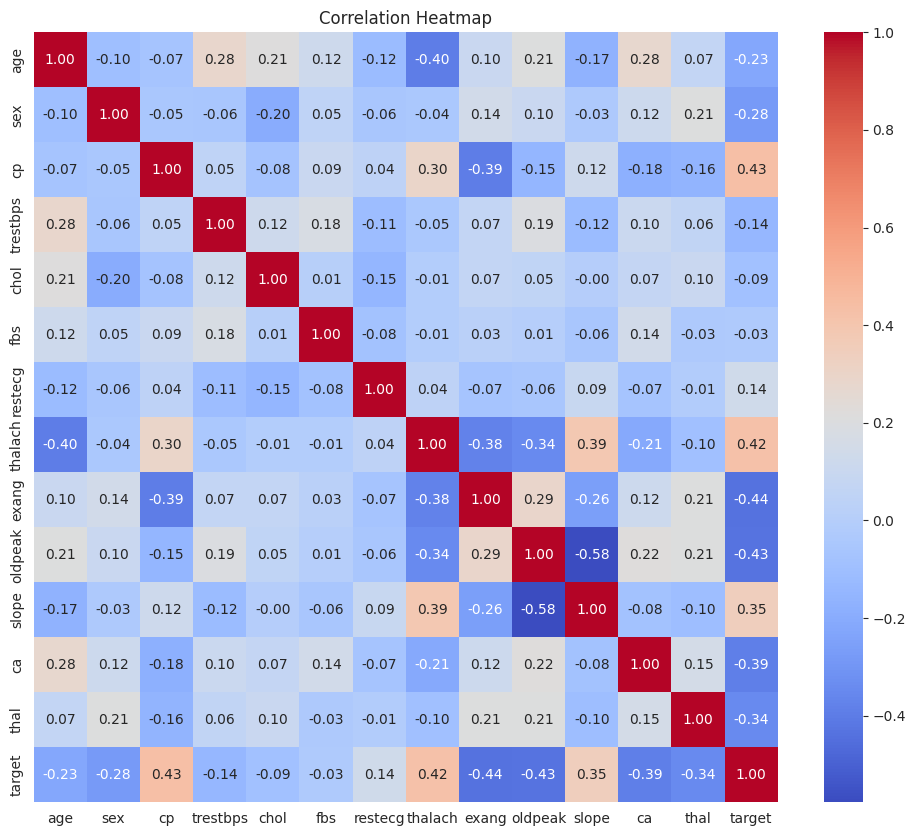

In [14]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

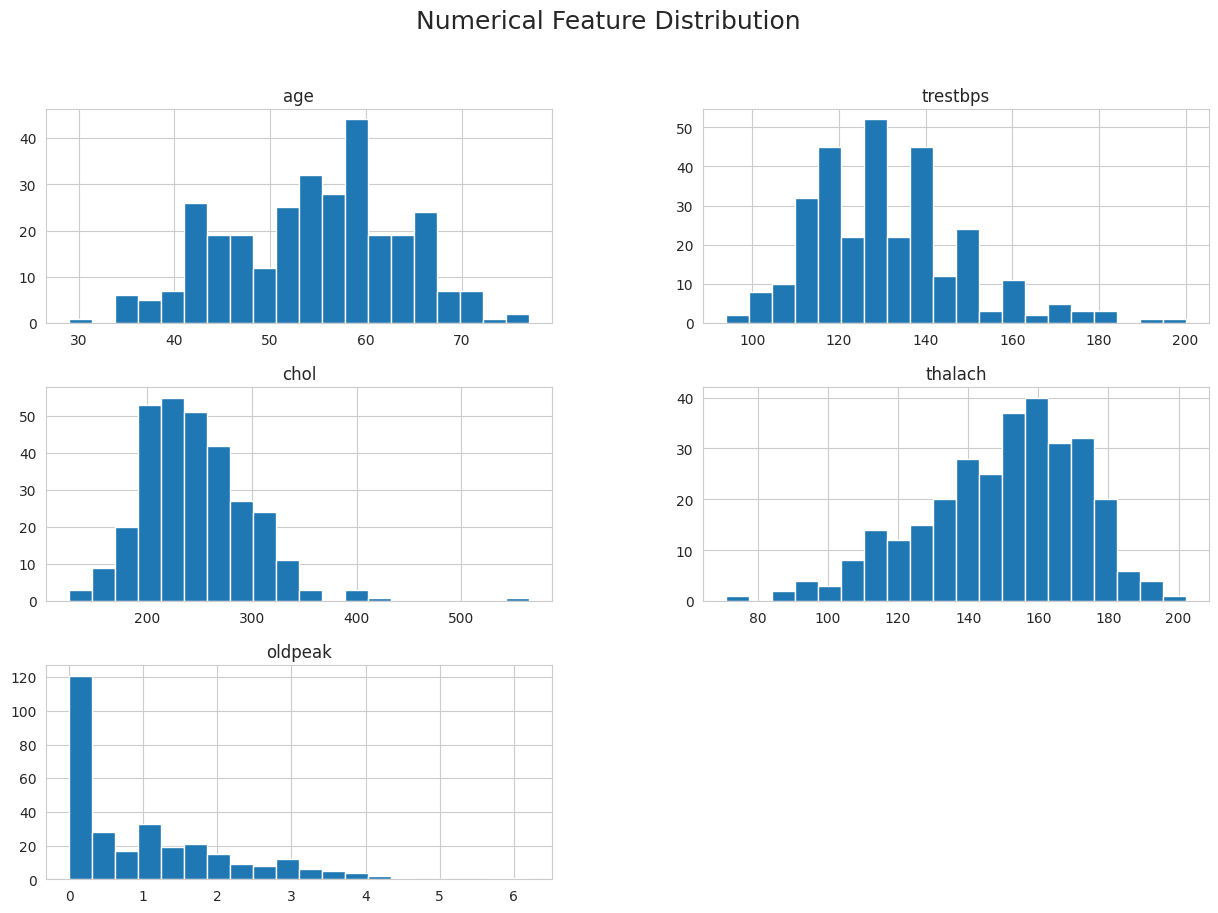

In [15]:
# ============================================================
# Numerical Feature Distribution
# ============================================================

numerical_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

df[numerical_features].hist(
    figsize=(15,10),
    bins=20
)

plt.suptitle("Numerical Feature Distribution", fontsize=18)

plt.show()

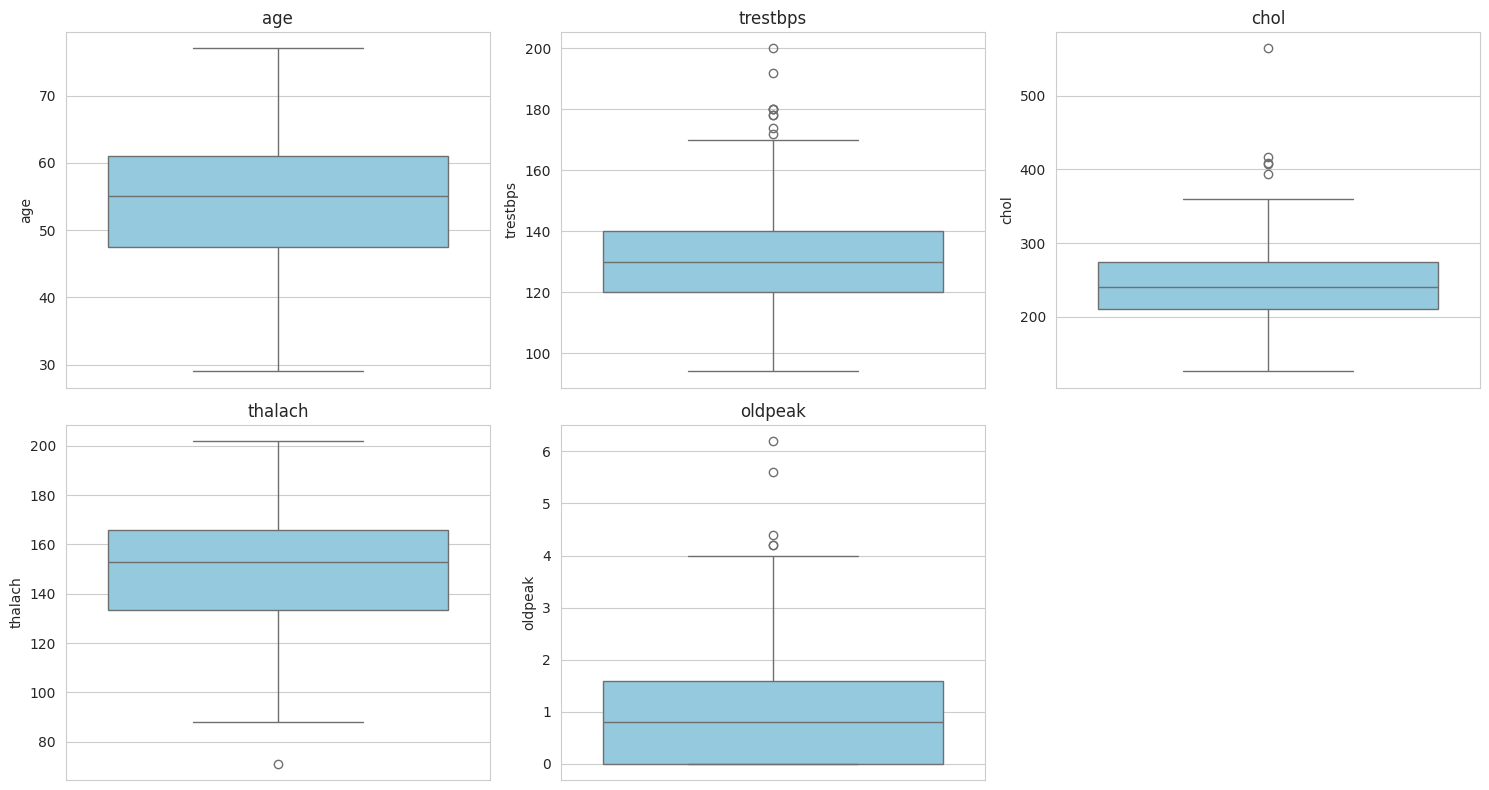

In [16]:
# ============================================================
# Outlier Detection
# ============================================================

plt.figure(figsize=(15,8))

for i, column in enumerate(numerical_features):

    plt.subplot(2,3,i+1)

    sns.boxplot(
        y=df[column],
        color="skyblue"
    )

    plt.title(column)

plt.tight_layout()

plt.show()

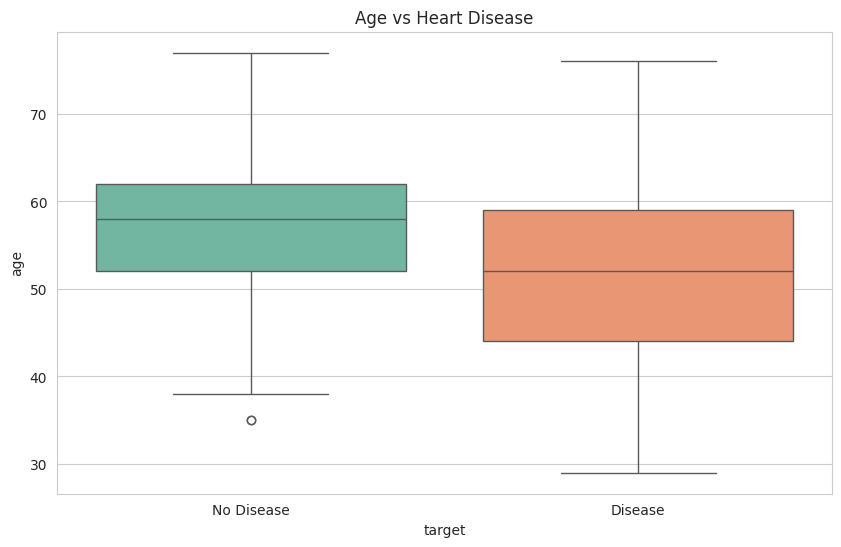

In [17]:
# ============================================================
# Heart Disease by Age
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='target',
    y='age',
    data=df,
    palette='Set2'
)

plt.xticks([0,1],["No Disease","Disease"])

plt.title("Age vs Heart Disease")

plt.show()

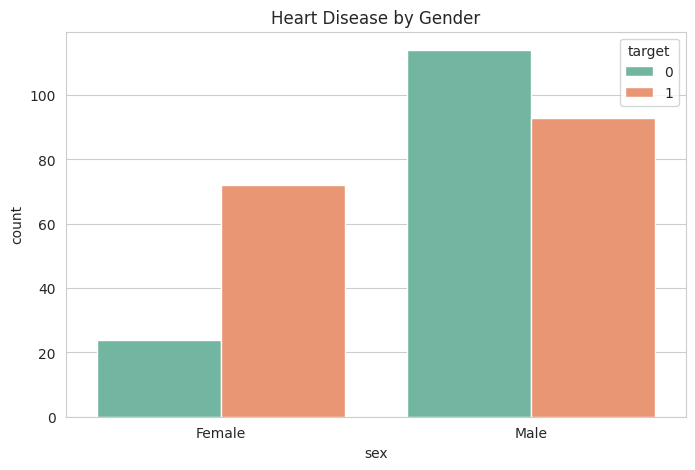

In [18]:
# ============================================================
# Heart Disease by Gender
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='sex',
    hue='target',
    data=df,
    palette='Set2'
)

plt.xticks([0,1],["Female","Male"])

plt.title("Heart Disease by Gender")

plt.show()

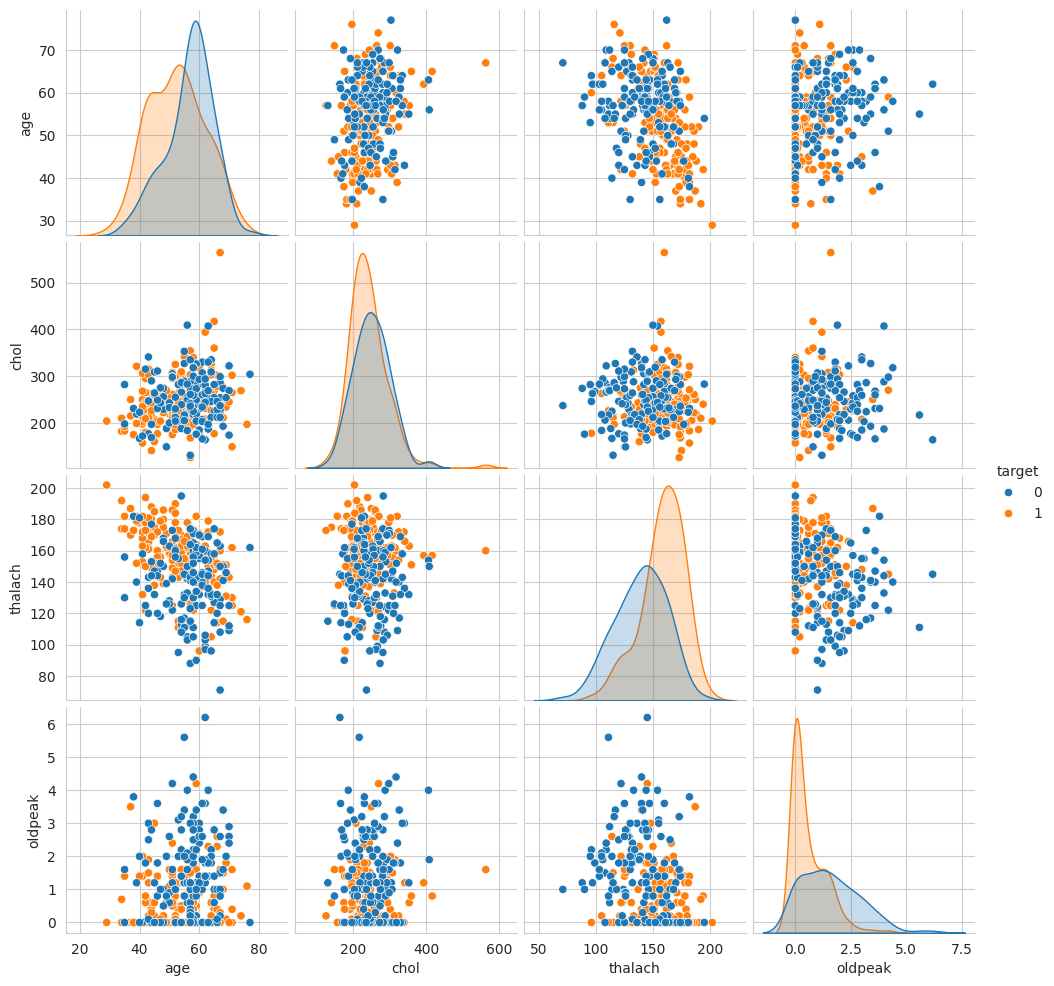

In [19]:
# ============================================================
# Pairplot
# ============================================================

selected_features = [
    "age",
    "chol",
    "thalach",
    "oldpeak",
    "target"
]

sns.pairplot(
    df[selected_features],
    hue="target"
)

plt.show()

In [20]:
# ============================================================
# Features and Target Variable
# ============================================================

X = df.drop("target", axis=1)
y = df["target"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

display(X.head())
display(y.head())

Feature Matrix Shape : (303, 13)
Target Vector Shape  : (303,)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


,target
0,1
1,1
2,1
3,1
4,1


In [21]:
# ============================================================
# Train Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 242
Testing Samples  : 61


In [22]:
# ============================================================
# Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


In [23]:
# ============================================================
# Machine Learning Models
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "Support Vector Machine":
        SVC(probability=True, random_state=42)

}

In [24]:
# ============================================================
# Model Training
# ============================================================

results = []

trained_models = {}

for name, model in models.items():

    if name in ["Logistic Regression", "Support Vector Machine"]:

        model.fit(X_train_scaled, y_train)

        predictions = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    results.append([

        name,
        accuracy,
        precision,
        recall,
        f1

    ])

    trained_models[name] = model

print("Training Completed Successfully!")

Training Completed Successfully!


In [25]:
# ============================================================
# Model Comparison
# ============================================================

results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ]

)

results_df = results_df.sort_values(

    by="Accuracy",

    ascending=False

)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.836066,0.780488,0.969697,0.864865
4,Support Vector Machine,0.819672,0.775000,0.939394,0.849315
3,Gradient Boosting,0.819672,0.789474,0.909091,0.845070
0,Logistic Regression,0.803279,0.769231,0.909091,0.833333
1,Decision Tree,0.704918,0.702703,0.787879,0.742857


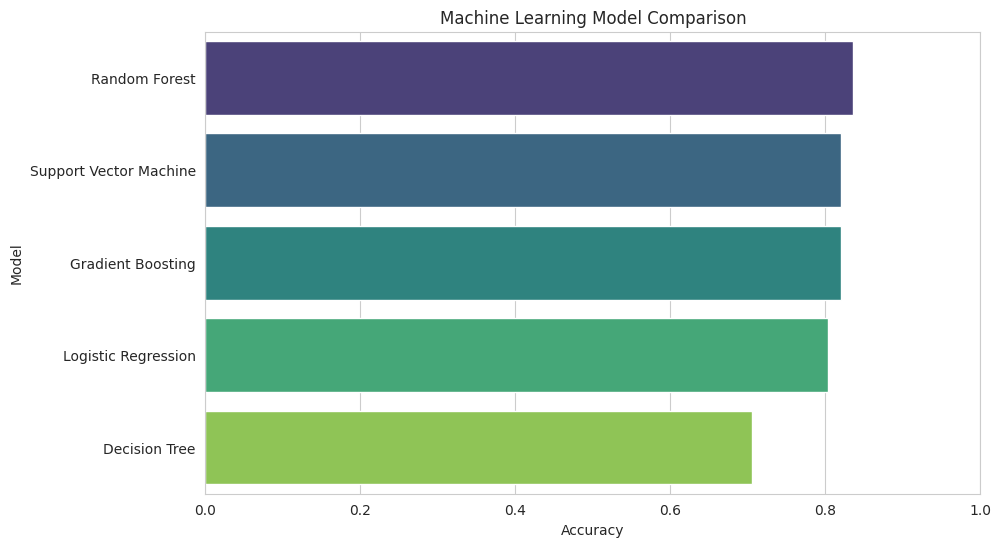

In [26]:
# ============================================================
# Model Accuracy Comparison
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(

    data=results_df,

    x="Accuracy",

    y="Model",

    palette="viridis"

)

plt.title("Machine Learning Model Comparison")

plt.xlim(0,1)

plt.show()

In [27]:
# ============================================================
# Best Model Selection
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("="*60)

print("Best Model :", best_model_name)

print("="*60)

Best Model : Random Forest


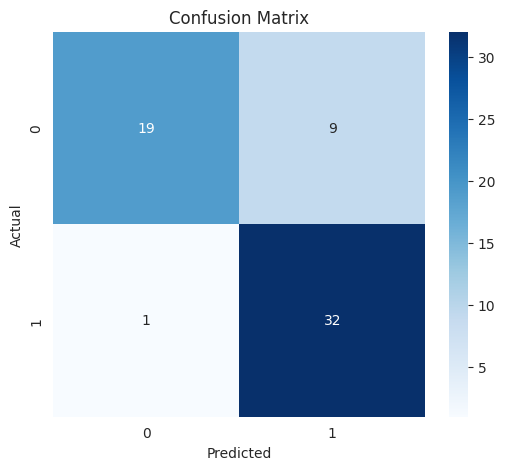

In [28]:
# ============================================================
# Confusion Matrix
# ============================================================

if best_model_name in ["Logistic Regression","Support Vector Machine"]:

    predictions = best_model.predict(X_test_scaled)

else:

    predictions = best_model.predict(X_test)

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [29]:
# ============================================================
# Classification Report
# ============================================================

print(classification_report(

    y_test,

    predictions

))

              precision    recall  f1-score   support

           0       0.95      0.68      0.79        28
           1       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61



In [30]:
# ============================================================
# Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score

print("="*60)
print("Cross Validation Results")
print("="*60)

cv_results = {}

for name, model in models.items():

    if name in ["Logistic Regression", "Support Vector Machine"]:

        scores = cross_val_score(
            model,
            scaler.fit_transform(X),
            y,
            cv=5,
            scoring="accuracy"
        )

    else:

        scores = cross_val_score(
            model,
            X,
            y,
            cv=5,
            scoring="accuracy"
        )

    cv_results[name] = scores.mean()

cv_df = pd.DataFrame({
    "Model": cv_results.keys(),
    "Cross Validation Accuracy": cv_results.values()
})

cv_df = cv_df.sort_values(
    by="Cross Validation Accuracy",
    ascending=False
)

display(cv_df)

Cross Validation Results


,Model,Cross Validation Accuracy
2,Random Forest,0.838197
0,Logistic Regression,0.834863
4,Support Vector Machine,0.818251
3,Gradient Boosting,0.814973
1,Decision Tree,0.755464


In [31]:
# ============================================================
# Hyperparameter Tuning
# ============================================================

from sklearn.model_selection import GridSearchCV

param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[None,5,10,15],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

grid_search = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_search.fit(X_train,y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters")

print(grid_search.best_params_)

print()

print("Best Cross Validation Accuracy")

print(grid_search.best_score_)

Best Parameters
{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}

Best Cross Validation Accuracy
0.8473639455782311


In [32]:
# ============================================================
# Tuned Random Forest Performance
# ============================================================

rf_predictions = best_rf.predict(X_test)

print("Accuracy")

print(accuracy_score(y_test,rf_predictions))

print()

print(classification_report(y_test,rf_predictions))

Accuracy
0.819672131147541

              precision    recall  f1-score   support

           0       0.95      0.64      0.77        28
           1       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



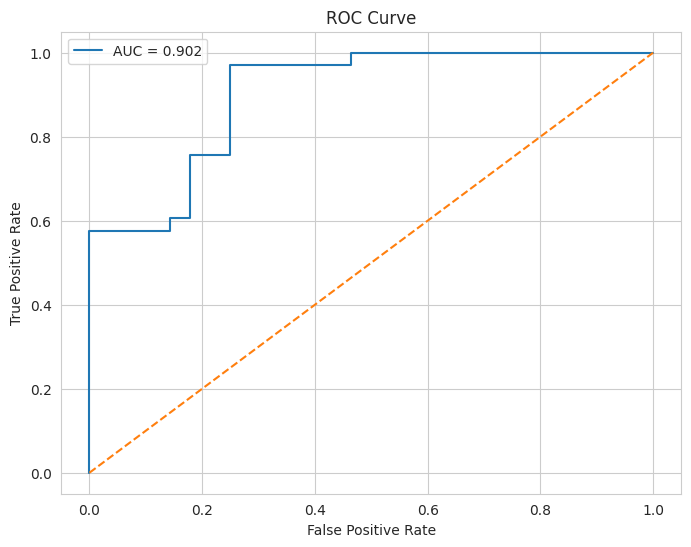

In [33]:
# ============================================================
# ROC Curve
# ============================================================

probabilities = best_rf.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,probabilities)

auc = roc_auc_score(y_test,probabilities)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

,Feature,Importance
2,cp,0.196888
12,thal,0.146814
7,thalach,0.107701
9,oldpeak,0.101896
11,ca,0.099499
8,exang,0.095696
10,slope,0.067539
4,chol,0.052743
0,age,0.051909
3,trestbps,0.036973


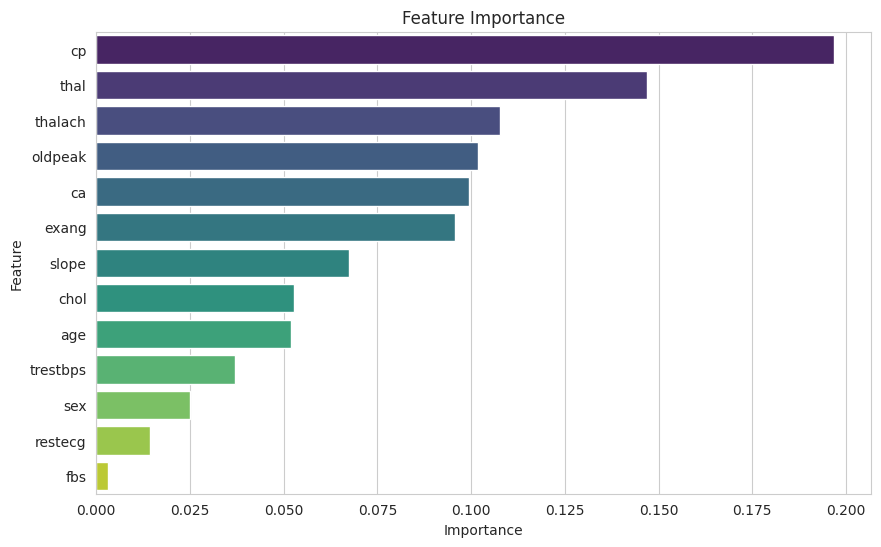

In [34]:
# ============================================================
# Feature Importance
# ============================================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(10,6))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Feature Importance")

plt.show()

,Feature,Importance
2,cp,0.196888
12,thal,0.146814
7,thalach,0.107701
9,oldpeak,0.101896
11,ca,0.099499
8,exang,0.095696
10,slope,0.067539
4,chol,0.052743
0,age,0.051909
3,trestbps,0.036973


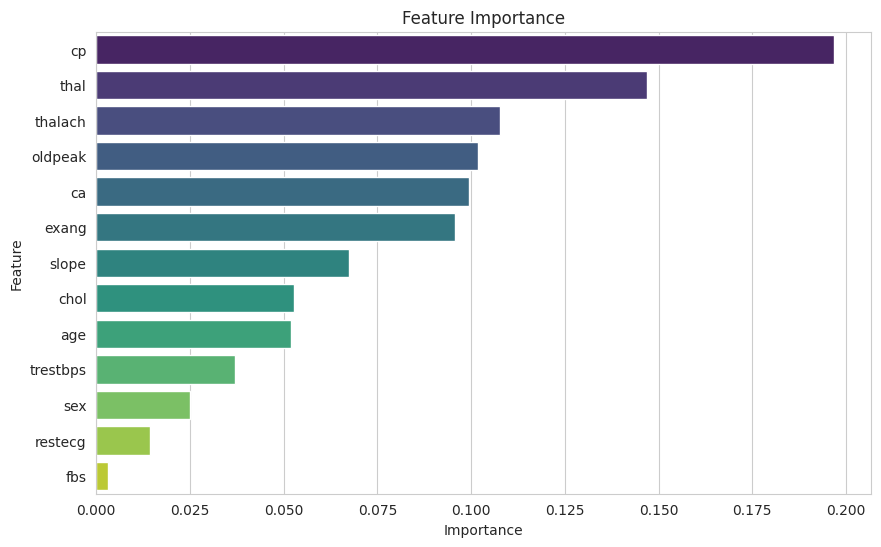

In [35]:
# ============================================================
# Feature Importance
# ============================================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(10,6))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Feature Importance")

plt.show()

In [36]:
# ============================================================
# Final Model
# ============================================================

final_model = best_rf

print("="*60)

print("Selected Model")

print(type(final_model).__name__)

print("="*60)

Selected Model
RandomForestClassifier


In [37]:
# ============================================================
# Save Model
# ============================================================

joblib.dump(

    final_model,

    "Disease_Prediction_Model.pkl"

)

joblib.dump(

    scaler,

    "scaler.pkl"

)

print("Model Saved Successfully!")

Model Saved Successfully!


In [38]:
# ============================================================
# Sample Prediction
# ============================================================

sample = X.iloc[[0]]

prediction = final_model.predict(sample)

probability = final_model.predict_proba(sample)

print("Prediction")

print(prediction)

print()

print("Probability")

print(probability)

Prediction
[1]

Probability
[[0.37014242 0.62985758]]


In [39]:
# ============================================================
# Download Files
# ============================================================

from google.colab import files

files.download("Disease_Prediction_Model.pkl")

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
# ============================================================
# Final Performance Summary
# ============================================================

print("="*70)
print("DISEASE PREDICTION MODEL PERFORMANCE SUMMARY")
print("="*70)

summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Value": [
        accuracy_score(y_test, rf_predictions),
        precision_score(y_test, rf_predictions),
        recall_score(y_test, rf_predictions),
        f1_score(y_test, rf_predictions),
        roc_auc_score(y_test, probabilities)
    ]
})

display(summary)

DISEASE PREDICTION MODEL PERFORMANCE SUMMARY


,Metric,Value
0,Accuracy,0.819672
1,Precision,0.761905
2,Recall,0.969697
3,F1 Score,0.853333
4,ROC AUC,0.901515


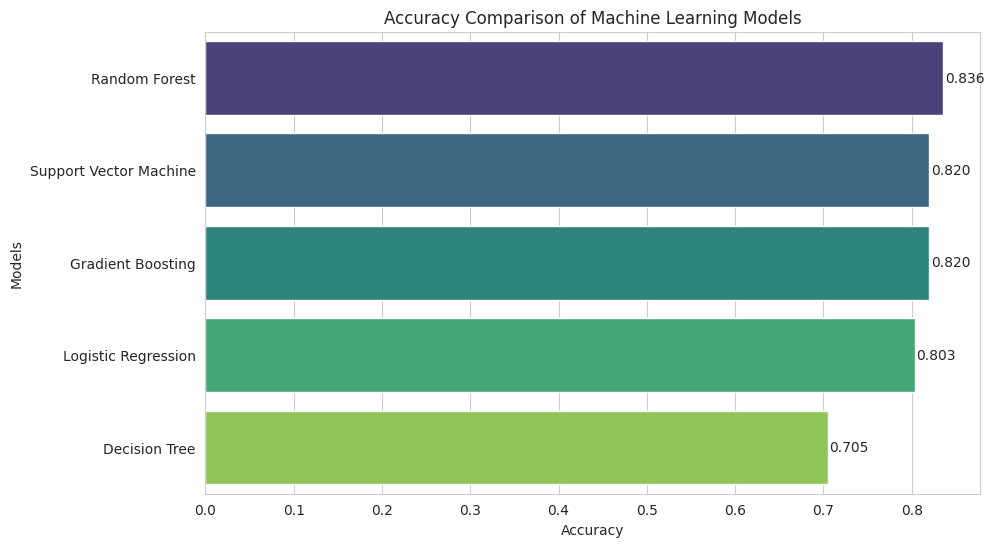

In [41]:
# ============================================================
# Model Performance Comparison
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Accuracy")
plt.ylabel("Models")

for index, value in enumerate(results_df["Accuracy"]):
    plt.text(
        value + 0.002,
        index,
        f"{value:.3f}",
        va="center"
    )

plt.show()

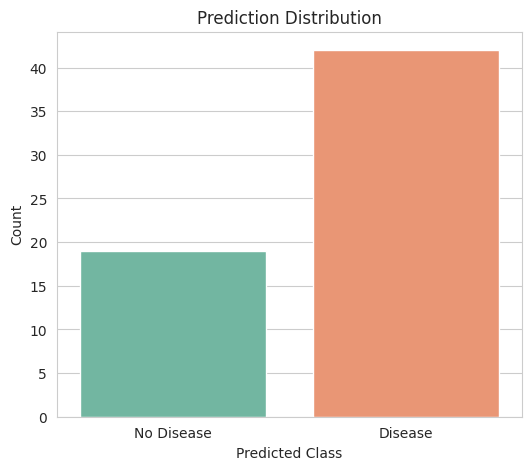

In [42]:
# ============================================================
# Prediction Distribution
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x=rf_predictions,
    palette="Set2"
)

plt.title("Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")

plt.xticks([0,1],["No Disease","Disease"])

plt.show()

In [43]:
# ============================================================
# Misclassified Samples
# ============================================================

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_predictions
})

errors = comparison[
    comparison["Actual"] != comparison["Predicted"]
]

print(f"Misclassified Samples: {len(errors)}")

display(errors.head(10))

Misclassified Samples: 11


,Actual,Predicted
3,0,1
4,0,1
9,0,1
10,1,0
20,0,1
23,0,1
36,0,1
40,0,1
45,0,1
47,0,1


#Conclusion

A machine learning model was successfully developed to predict the presence of heart disease based on patient clinical information.

Multiple machine learning algorithms, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and Support Vector Machine, were trained and evaluated. Performance was assessed using accuracy, precision, recall, F1-score, and ROC-AUC metrics.

The selected model exhibited robust predictive performance and demonstrated effective generalization through cross-validation. Feature importance analysis identified the clinical variables that contributed most to prediction, thereby enhancing interpretability.

The trained model was exported and is prepared for integration into a Flask web application to enable real-time disease prediction.

#Directions for Future Research

Several potential improvements can be considered can be considered can be considered can be considered can be considered:

* The collection of larger and more diverse patient datasets.
* The exploration of deep learning methodologies.
* Optimization of hyperparameters through Bayesian Optimization.
* Development of a REST API.
* Deployment of the application
* on platforms such as Render or Railway.
* Adding patient authentication and prediction history.
* Monitoring model performance after deployment.

In [44]:
# ============================================================
# Project Completed
# ============================================================

print("="*70)
print("Heart Disease Prediction Project Completed Successfully!")
print("="*70)

print("Notebook Status")
print("Completed")

print("Machine Learning Models")
print(len(models))

print("Best Model")
print(type(final_model).__name__)

print("Ready for Flask Deployment")
print("Yes")

Heart Disease Prediction Project Completed Successfully!
Notebook Status
Completed
Machine Learning Models
5
Best Model
RandomForestClassifier
Ready for Flask Deployment
Yes
